In [1]:
import pandas as pd
import numpy as np
import pickle
import os

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [2]:
BASE_PATH = "../Data"

isot_df = pd.read_csv(os.path.join(BASE_PATH, "ISOT", "isot_cleaned.csv"))
welfake_df = pd.read_csv(os.path.join(BASE_PATH, "WELFake", "welfake_cleaned.csv"))

# Fix missing values
isot_df["content"] = isot_df["content"].fillna("").astype(str)
welfake_df["content"] = welfake_df["content"].fillna("").astype(str)

print("ISOT:", isot_df.shape)
print("WELFake:", welfake_df.shape)

ISOT: (38827, 2)
WELFake: (62749, 2)


In [3]:
from sklearn.model_selection import train_test_split

# ISOT
X_train_isot, X_test_isot, y_train_isot, y_test_isot = train_test_split(
    isot_df["content"], isot_df["label"], test_size=0.2, random_state=42
)

# WELFake
X_train_wel, X_test_wel, y_train_wel, y_test_wel = train_test_split(
    welfake_df["content"], welfake_df["label"], test_size=0.2, random_state=42
)

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_isot = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,3),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True
)

X_train_isot_tfidf = tfidf_isot.fit_transform(X_train_isot)
X_test_isot_tfidf = tfidf_isot.transform(X_test_isot)


tfidf_welfake = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,3),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True
)

X_train_wel_tfidf = tfidf_welfake.fit_transform(X_train_wel)
X_test_wel_tfidf = tfidf_welfake.transform(X_test_wel)

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced'),

    "Naive Bayes": MultinomialNB(),

    "SVM": LinearSVC(class_weight='balanced', C=1.5),

    "Gradient Boosting": GradientBoostingClassifier(),

    "XGBoost": XGBClassifier(
        n_estimators=400,
        max_depth=10,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss',
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=10
    )
}

In [6]:
def evaluate_model(model, X, y):
    pred = model.predict(X)

    return {
        "Accuracy": accuracy_score(y, pred),
        "Precision": precision_score(y, pred),
        "Recall": recall_score(y, pred),
        "F1 Score": f1_score(y, pred)
    }

In [7]:
results_isot = []

for name, model in models.items():
    print(f"Training {name} on ISOT...")

    model.fit(X_train_isot_tfidf, y_train_isot)

    metrics = evaluate_model(model, X_test_isot_tfidf, y_test_isot)

    metrics["Model"] = name
    metrics["Dataset"] = "ISOT"

    results_isot.append(metrics)

df_isot = pd.DataFrame(results_isot)
df_isot

Training Logistic Regression on ISOT...
Training Naive Bayes on ISOT...
Training SVM on ISOT...
Training Gradient Boosting on ISOT...
Training XGBoost on ISOT...
Training LightGBM on ISOT...
[LightGBM] [Info] Number of positive: 14327, number of negative: 16734
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.617743 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1194947
[LightGBM] [Info] Number of data points in the train set: 31061, number of used features: 14962
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.461254 -> initscore=-0.155297
[LightGBM] [Info] Start training from score -0.155297


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Accuracy,Precision,Recall,F1 Score,Model,Dataset
0,0.988797,0.991829,0.983790,0.987793,Logistic Regression,ISOT
1,0.961241,0.956280,0.959754,0.958014,Naive Bayes,ISOT
2,0.992532,0.993827,0.989939,0.991879,SVM,ISOT
3,0.978625,0.985487,0.967859,0.976593,Gradient Boosting,ISOT
4,0.987767,0.989323,0.984069,0.986689,XGBoost,ISOT
5,0.989827,0.992124,0.985746,0.988925,LightGBM,ISOT


In [8]:
results_welfake = []

for name, model in models.items():
    print(f"Training {name} on WELFake...")

    model.fit(X_train_wel_tfidf, y_train_wel)

    metrics = evaluate_model(model, X_test_wel_tfidf, y_test_wel)

    metrics["Model"] = name
    metrics["Dataset"] = "WELFake"

    results_welfake.append(metrics)

df_welfake = pd.DataFrame(results_welfake)
df_welfake

Training Logistic Regression on WELFake...
Training Naive Bayes on WELFake...
Training SVM on WELFake...
Training Gradient Boosting on WELFake...
Training XGBoost on WELFake...
Training LightGBM on WELFake...
[LightGBM] [Info] Number of positive: 22502, number of negative: 27697
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.067989 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1846321
[LightGBM] [Info] Number of data points in the train set: 50199, number of used features: 14987
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448256 -> initscore=-0.207720
[LightGBM] [Info] Start training from score -0.207720


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Accuracy,Precision,Recall,F1 Score,Model,Dataset
0,0.960239,0.954017,0.959177,0.956590,Logistic Regression,WELFake
1,0.876653,0.849365,0.887299,0.867918,Naive Bayes,WELFake
2,0.963904,0.959443,0.961619,0.960530,SVM,WELFake
3,0.923825,0.920275,0.912247,0.916243,Gradient Boosting,WELFake
4,0.957371,0.954840,0.951675,0.953255,XGBoost,WELFake
5,0.960637,0.959635,0.953943,0.956780,LightGBM,WELFake


In [9]:
cross_results_1 = []

for name, model in models.items():
    model.fit(X_train_isot_tfidf, y_train_isot)

    pred = model.predict(tfidf_isot.transform(X_test_wel))

    metrics = {
        "Accuracy": accuracy_score(y_test_wel, pred),
        "Precision": precision_score(y_test_wel, pred),
        "Recall": recall_score(y_test_wel, pred),
        "F1 Score": f1_score(y_test_wel, pred),
        "Model": name,
        "Dataset": "ISOT → WELFake"
    }

    cross_results_1.append(metrics)

df_cross1 = pd.DataFrame(cross_results_1)
df_cross1

[LightGBM] [Info] Number of positive: 14327, number of negative: 16734
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.620765 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1194947
[LightGBM] [Info] Number of data points in the train set: 31061, number of used features: 14962
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.461254 -> initscore=-0.155297
[LightGBM] [Info] Start training from score -0.155297


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Accuracy,Precision,Recall,F1 Score,Model,Dataset
0,0.835618,0.753629,0.950977,0.840879,Logistic Regression,ISOT → WELFake
1,0.801195,0.729347,0.897941,0.804910,Naive Bayes,ISOT → WELFake
2,0.837769,0.753986,0.957083,0.843481,SVM,ISOT → WELFake
3,0.860000,0.816733,0.894103,0.853669,Gradient Boosting,ISOT → WELFake
4,0.866375,0.798118,0.946964,0.866193,XGBoost,ISOT → WELFake
5,0.863904,0.794842,0.946267,0.863969,LightGBM,ISOT → WELFake


In [10]:
cross_results_2 = []

for name, model in models.items():
    model.fit(X_train_wel_tfidf, y_train_wel)

    pred = model.predict(tfidf_welfake.transform(X_test_isot))

    metrics = {
        "Accuracy": accuracy_score(y_test_isot, pred),
        "Precision": precision_score(y_test_isot, pred),
        "Recall": recall_score(y_test_isot, pred),
        "F1 Score": f1_score(y_test_isot, pred),
        "Model": name,
        "Dataset": "WELFake → ISOT"
    }

    cross_results_2.append(metrics)

df_cross2 = pd.DataFrame(cross_results_2)
df_cross2

[LightGBM] [Info] Number of positive: 22502, number of negative: 27697
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.120792 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1846321
[LightGBM] [Info] Number of data points in the train set: 50199, number of used features: 14987
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448256 -> initscore=-0.207720
[LightGBM] [Info] Start training from score -0.207720


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Accuracy,Precision,Recall,F1 Score,Model,Dataset
0,0.985449,0.995708,0.972610,0.984024,Logistic Regression,WELFake → ISOT
1,0.961241,0.986635,0.928452,0.956659,Naive Bayes,WELFake → ISOT
2,0.996008,0.997755,0.993572,0.995659,SVM,WELFake → ISOT
3,0.958280,0.964857,0.943823,0.954224,Gradient Boosting,WELFake → ISOT
4,0.993690,0.996343,0.989939,0.993131,XGBoost,WELFake → ISOT
5,0.991888,0.995769,0.986585,0.991155,LightGBM,WELFake → ISOT


In [11]:
final_results = pd.concat([df_isot, df_welfake, df_cross1, df_cross2], ignore_index=True)

print("Final Combined Results:")
final_results

Final Combined Results:


,Accuracy,Precision,Recall,F1 Score,Model,Dataset
0,0.988797,0.991829,0.983790,0.987793,Logistic Regression,ISOT
1,0.961241,0.956280,0.959754,0.958014,Naive Bayes,ISOT
2,0.992532,0.993827,0.989939,0.991879,SVM,ISOT
3,0.978625,0.985487,0.967859,0.976593,Gradient Boosting,ISOT
4,0.987767,0.989323,0.984069,0.986689,XGBoost,ISOT
5,0.989827,0.992124,0.985746,0.988925,LightGBM,ISOT
6,0.960239,0.954017,0.959177,0.956590,Logistic Regression,WELFake
7,0.876653,0.849365,0.887299,0.867918,Naive Bayes,WELFake
8,0.963904,0.959443,0.961619,0.960530,SVM,WELFake
9,0.923825,0.920275,0.912247,0.916243,Gradient Boosting,WELFake


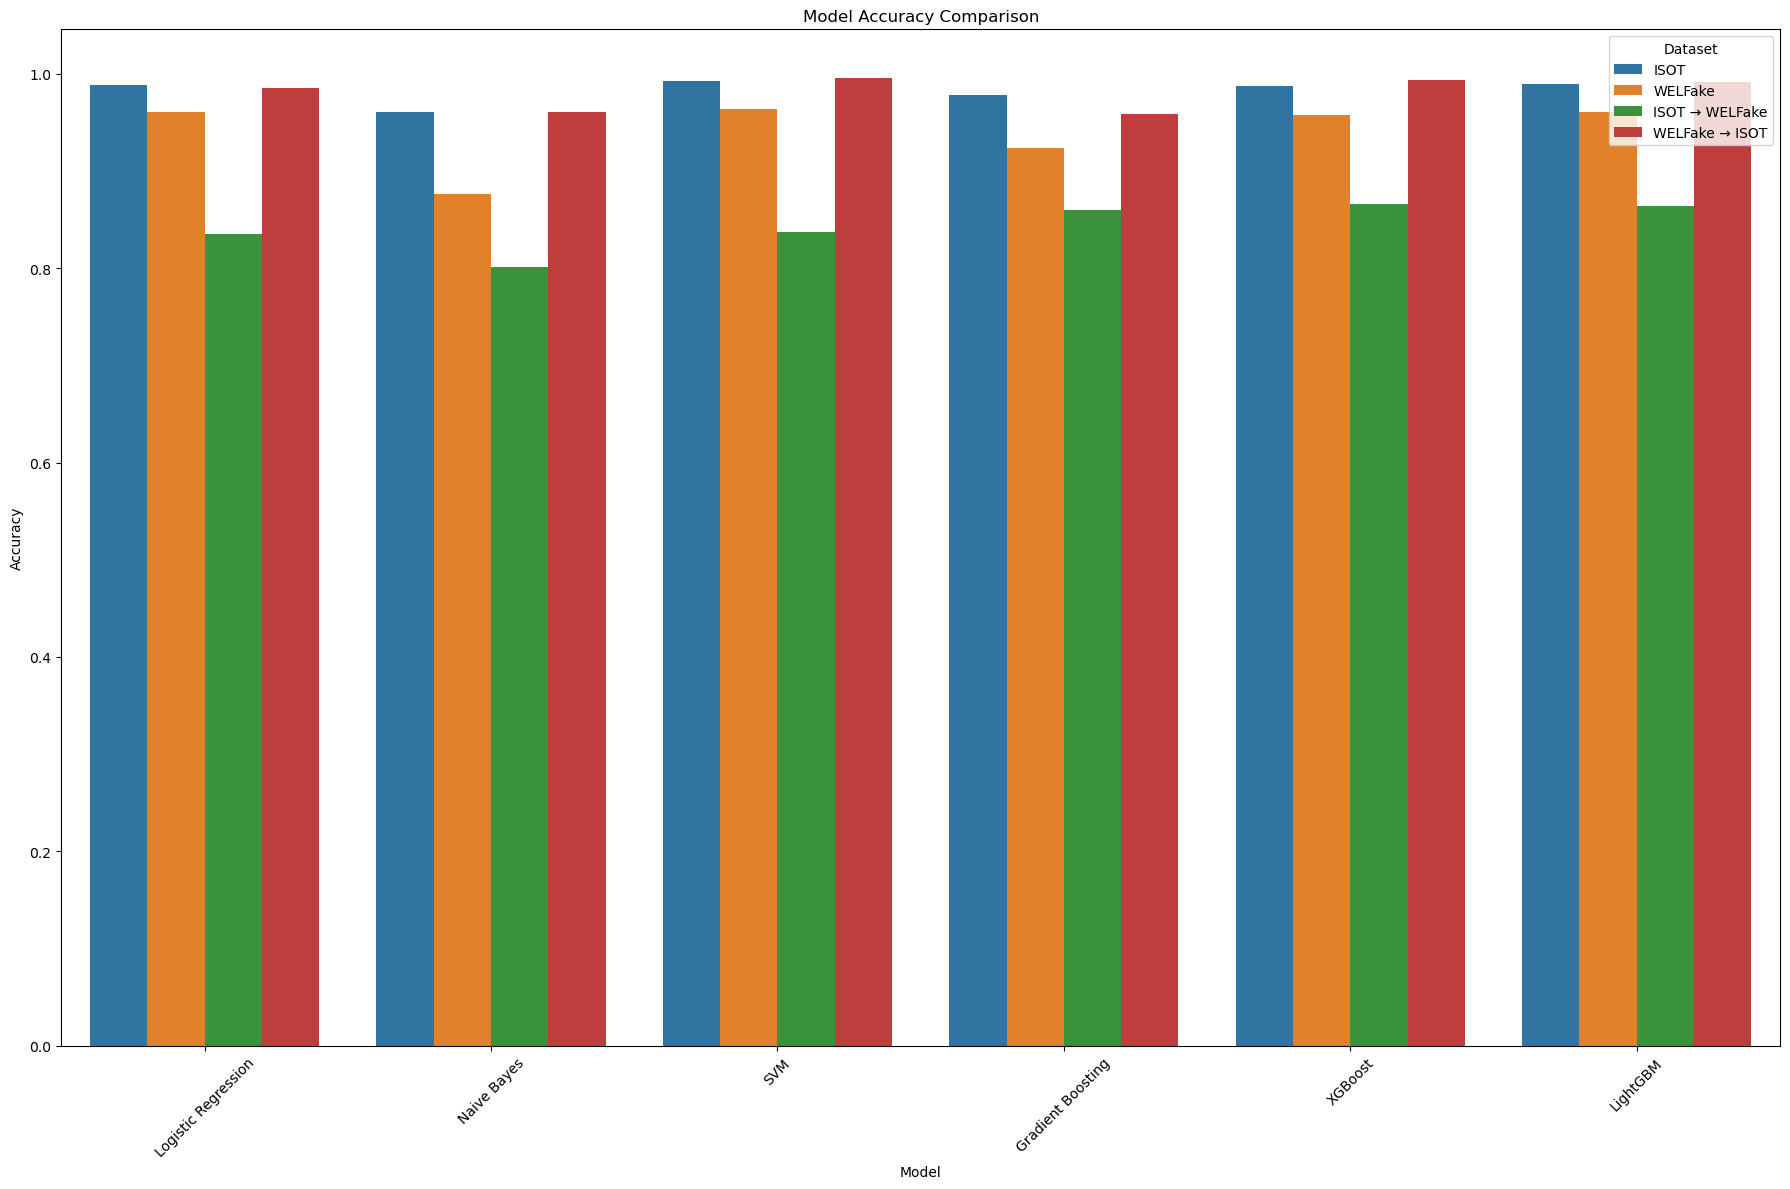

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18,12))

ax = sns.barplot(
    data=final_results,
    x="Model",
    y="Accuracy",
    hue="Dataset"
)



plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

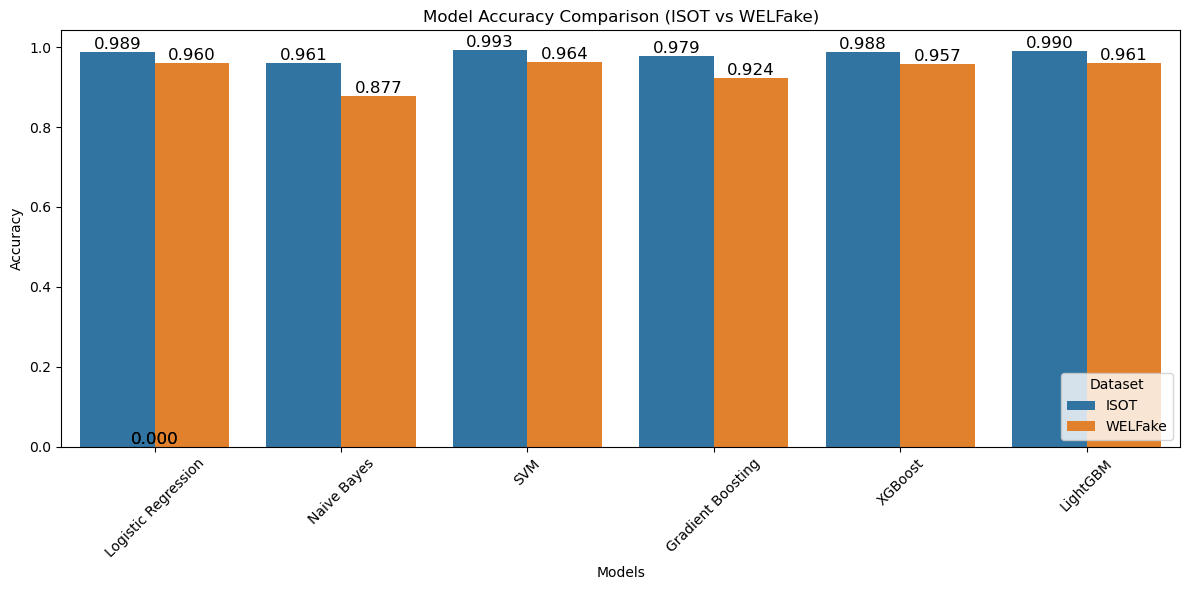

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

df_main = final_results[
    final_results["Dataset"].isin(["ISOT", "WELFake"])
]

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=df_main,
    x="Model",
    y="Accuracy",
    hue="Dataset"
)

# ✅ Add values
for p in ax.patches:
    height = p.get_height()
    if not (height is None or height != height):  # avoid NaN
        ax.annotate(
            f'{height:.3f}',
            (p.get_x() + p.get_width()/2, height),
            ha='center',
            va='bottom',
            fontsize=12,
            rotation=0
        )

plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison (ISOT vs WELFake)")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

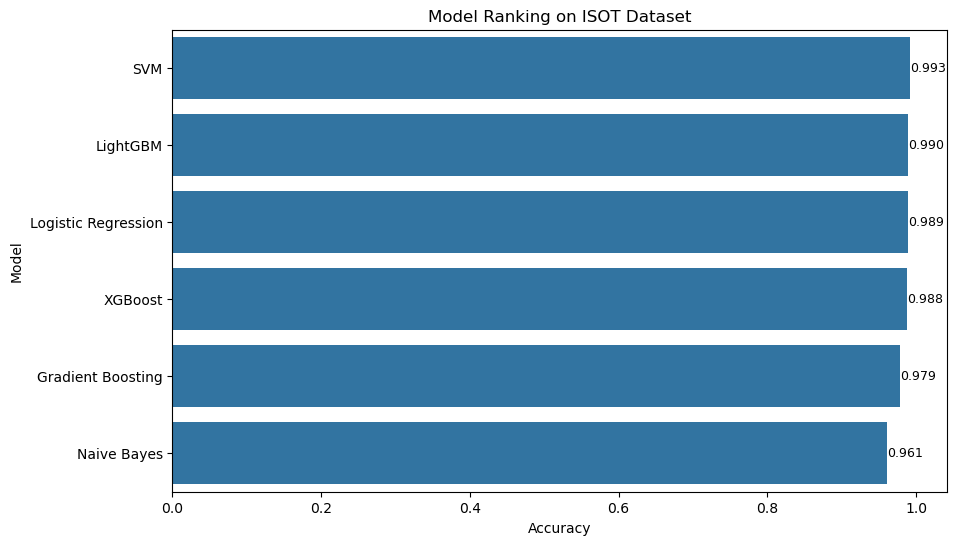

In [14]:
df_isot = final_results[final_results["Dataset"] == "ISOT"]
df_isot_sorted = df_isot.sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=df_isot_sorted,
    x="Accuracy",
    y="Model"
)

# ✅ Add values
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{width:.3f}',
        (width, p.get_y() + p.get_height()/2),
        ha='left',
        va='center',
        fontsize=9
    )

plt.title("Model Ranking on ISOT Dataset")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.show()

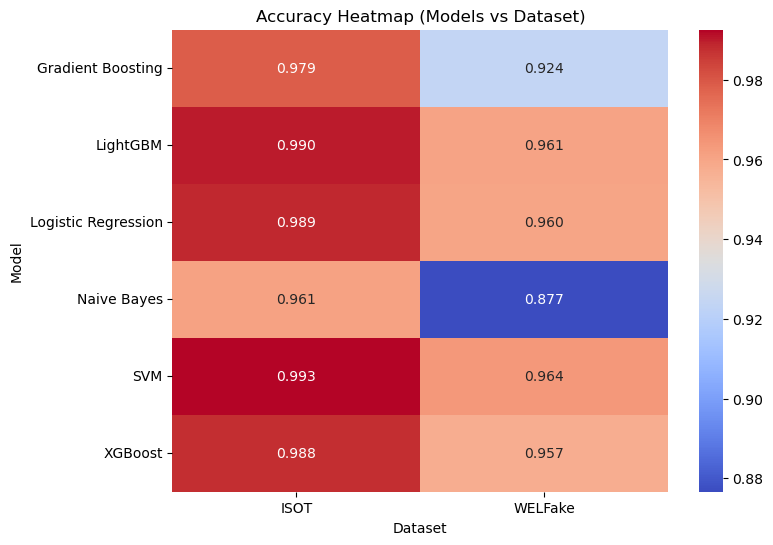

In [15]:
pivot = df_main.pivot_table(
    index="Model",
    columns="Dataset",
    values="Accuracy"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="coolwarm",
    fmt=".3f"
)

plt.title("Accuracy Heatmap (Models vs Dataset)")
plt.xlabel("Dataset")
plt.ylabel("Model")

plt.show()

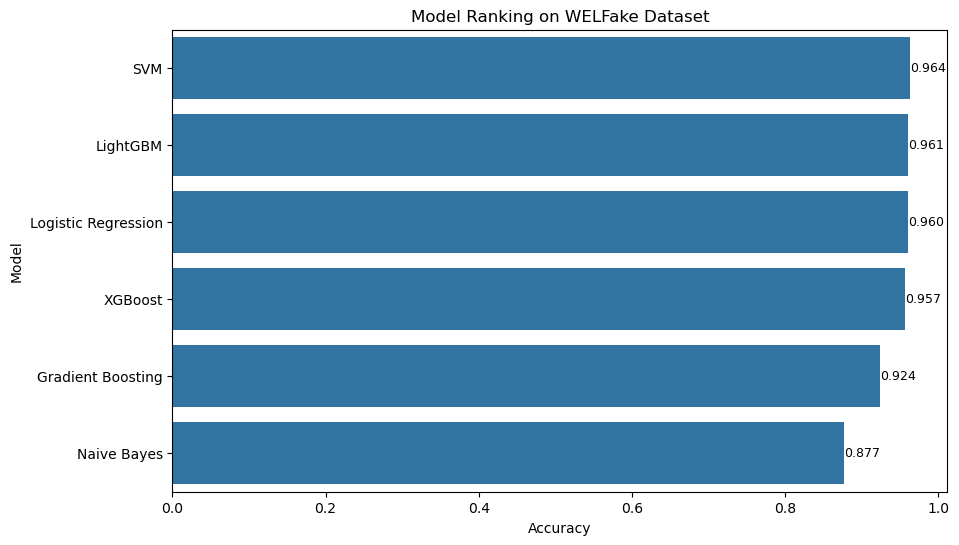

In [16]:
df_wel = final_results[final_results["Dataset"] == "WELFake"]
df_wel_sorted = df_wel.sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=df_wel_sorted,
    x="Accuracy",
    y="Model"
)

# ✅ Add values
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{width:.3f}',
        (width, p.get_y() + p.get_height()/2),
        ha='left',
        va='center',
        fontsize=9
    )

plt.title("Model Ranking on WELFake Dataset")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.show()

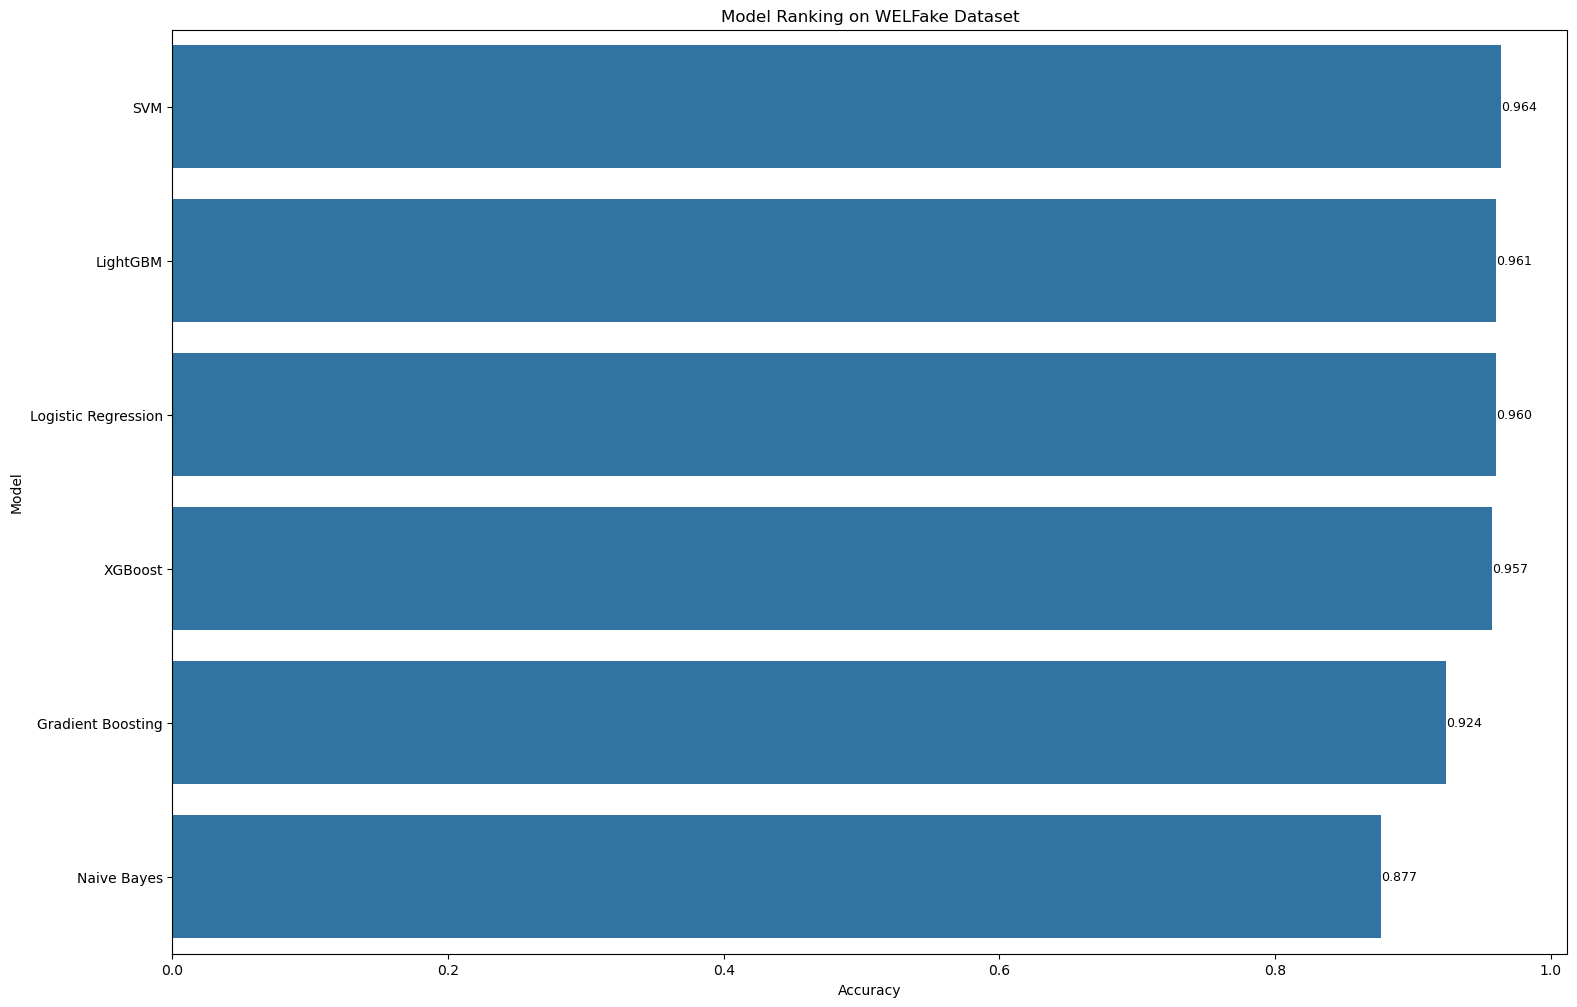

In [17]:
df_wel = final_results[final_results["Dataset"] == "WELFake"]
df_wel_sorted = df_wel.sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(18,12))

ax = sns.barplot(
    data=df_wel_sorted,
    x="Accuracy",
    y="Model"
)

# ✅ Add values
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{width:.3f}',
        (width, p.get_y() + p.get_height()/2),
        ha='left',
        va='center',
        fontsize=9
    )

plt.title("Model Ranking on WELFake Dataset")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.show()

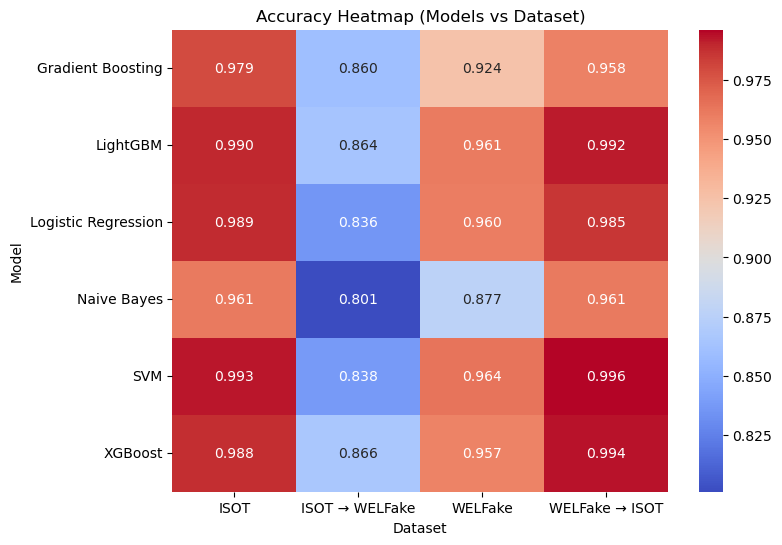

In [18]:
pivot = final_results.pivot_table(
    index="Model",
    columns="Dataset",
    values="Accuracy"
)

plt.figure(figsize=(8,6))

sns.heatmap(pivot, annot=True, cmap="coolwarm", fmt=".3f")

plt.title("Accuracy Heatmap (Models vs Dataset)")
plt.show()

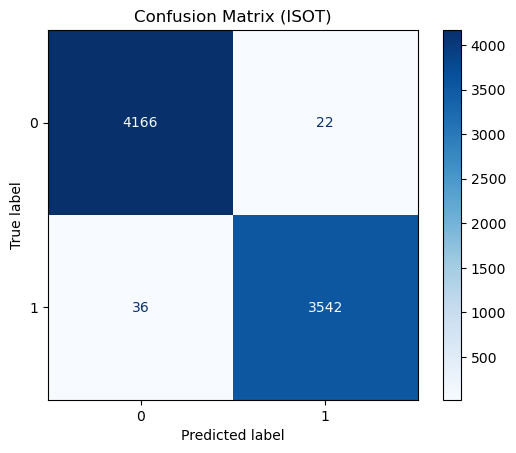

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model = models["SVM"]   # best model

model.fit(X_train_isot_tfidf, y_train_isot)
y_pred = model.predict(X_test_isot_tfidf)

cm = confusion_matrix(y_test_isot, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix (ISOT)")
plt.show()

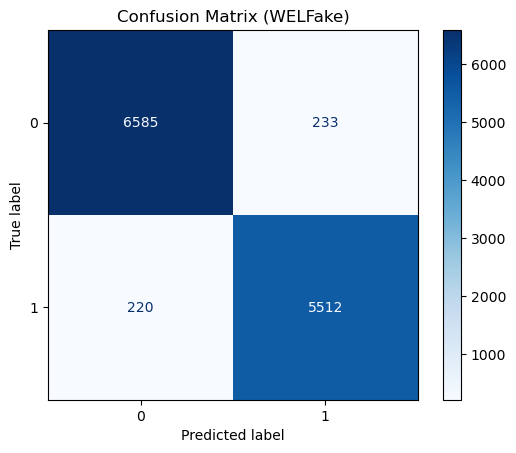

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Select model
model = models["SVM"]   # best model

# Train on WELFake
model.fit(X_train_wel_tfidf, y_train_wel)

# Predict
y_pred = model.predict(X_test_wel_tfidf)

# Confusion Matrix
cm = confusion_matrix(y_test_wel, y_pred)

# Display
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix (WELFake)")
plt.show()


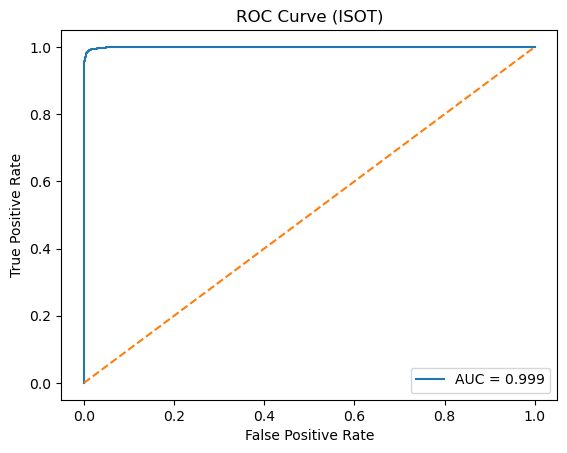

In [21]:
from sklearn.metrics import roc_curve, auc

model = models["Logistic Regression"]

model.fit(X_train_isot_tfidf, y_train_isot)
y_prob = model.predict_proba(X_test_isot_tfidf)[:,1]

fpr, tpr, _ = roc_curve(y_test_isot, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (ISOT)")
plt.legend()

plt.show()

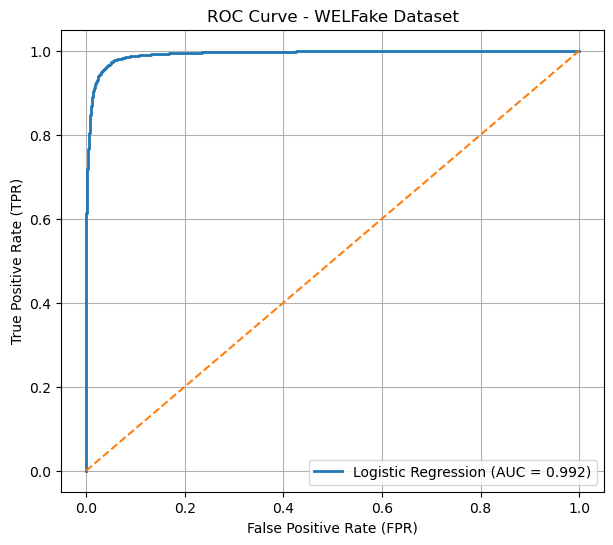

In [22]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Select model
model = models["Logistic Regression"]

# Train model
model.fit(X_train_wel_tfidf, y_train_wel)

# Predict probabilities
y_prob = model.predict_proba(X_test_wel_tfidf)[:, 1]

# Calculate ROC
fpr, tpr, _ = roc_curve(y_test_wel, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, linewidth=2, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")  # random baseline

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - WELFake Dataset")
plt.legend(loc="lower right")

plt.grid(True)   # 🔥 adds grid (better look)

plt.show()

In [25]:
top_models = final_results.sort_values(by="Accuracy", ascending=False).head(10)

print(top_models)

    Accuracy  Precision    Recall  F1 Score                Model  \
20  0.996008   0.997755  0.993572  0.995659                  SVM   
22  0.993690   0.996343  0.989939  0.993131              XGBoost   
2   0.992532   0.993827  0.989939  0.991879                  SVM   
23  0.991888   0.995769  0.986585  0.991155             LightGBM   
5   0.989827   0.992124  0.985746  0.988925             LightGBM   
0   0.988797   0.991829  0.983790  0.987793  Logistic Regression   
4   0.987767   0.989323  0.984069  0.986689              XGBoost   
18  0.985449   0.995708  0.972610  0.984024  Logistic Regression   
3   0.978625   0.985487  0.967859  0.976593    Gradient Boosting   
8   0.963904   0.959443  0.961619  0.960530                  SVM   

           Dataset  
20  WELFake → ISOT  
22  WELFake → ISOT  
2             ISOT  
23  WELFake → ISOT  
5             ISOT  
0             ISOT  
4             ISOT  
18  WELFake → ISOT  
3             ISOT  
8          WELFake  


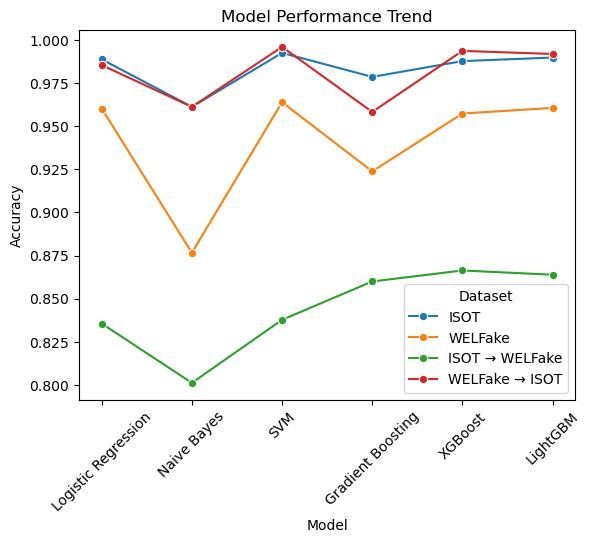

In [26]:
sns.lineplot(
    data=final_results,
    x="Model",
    y="Accuracy",
    hue="Dataset",
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Model Performance Trend")

plt.show()

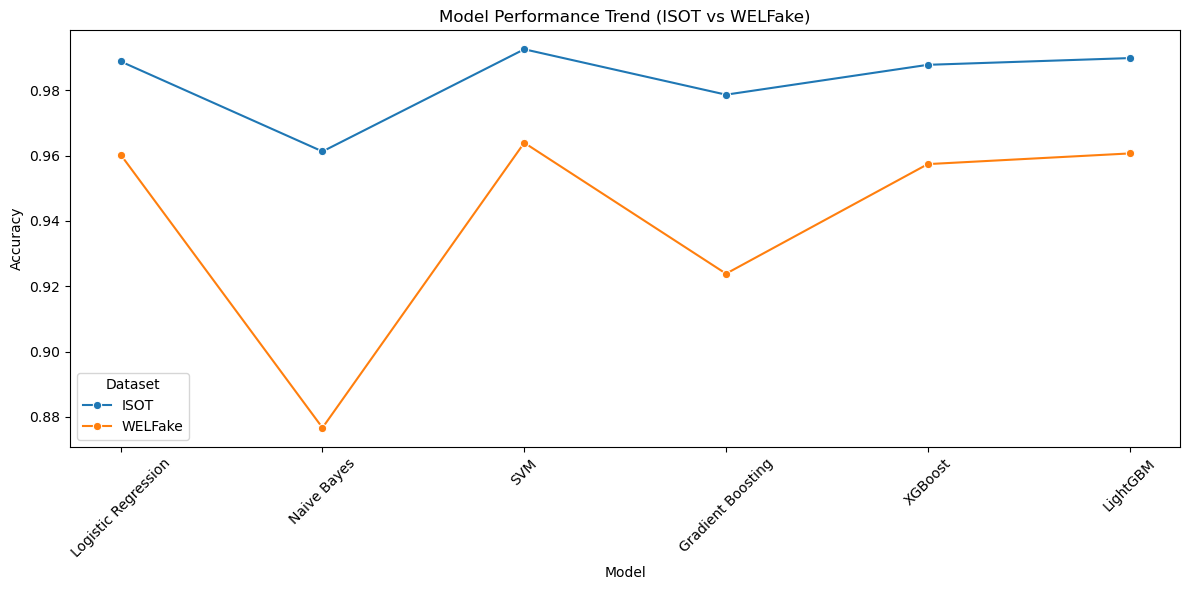

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ Filter only main datasets
df_main = final_results[
    final_results["Dataset"].isin(["ISOT", "WELFake"])
]

plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_main,
    x="Model",
    y="Accuracy",
    hue="Dataset",
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Model Performance Trend (ISOT vs WELFake)")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.legend(title="Dataset")

plt.tight_layout()
plt.show()

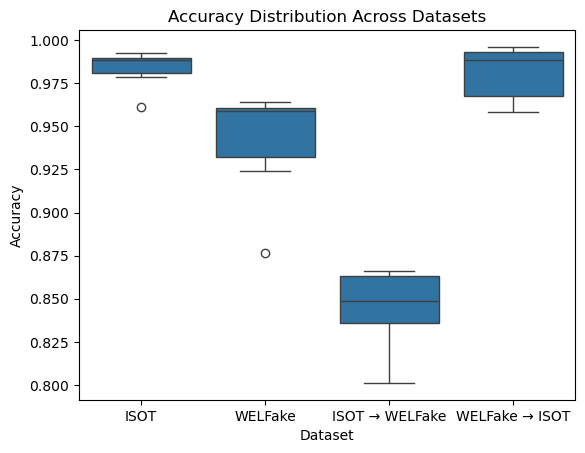

In [27]:
sns.boxplot(
    data=final_results,
    x="Dataset",
    y="Accuracy"
)

plt.title("Accuracy Distribution Across Datasets")
plt.show()

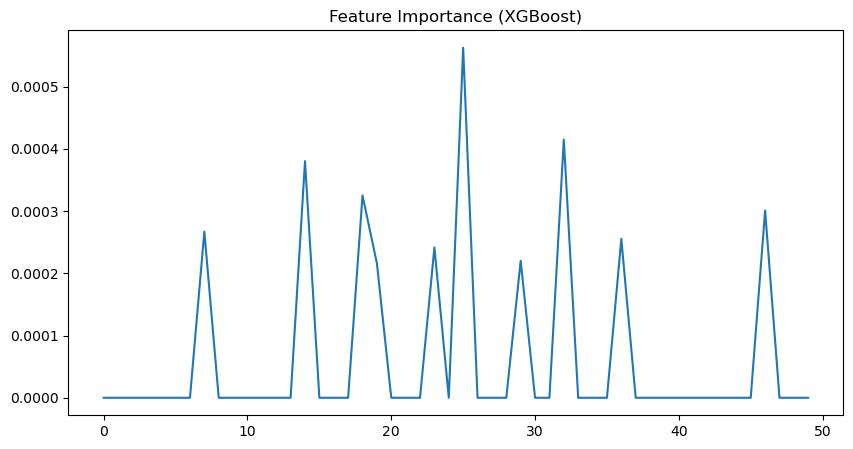

In [28]:
importances = models["XGBoost"].feature_importances_

plt.figure(figsize=(10,5))
plt.plot(importances[:50])  # first 50 features

plt.title("Feature Importance (XGBoost)")
plt.show()

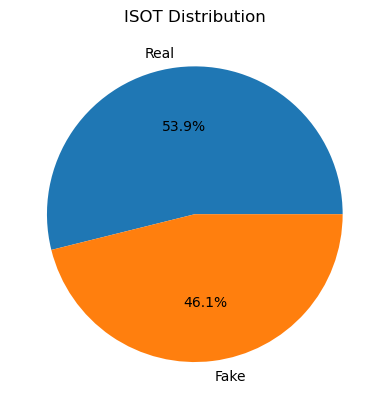

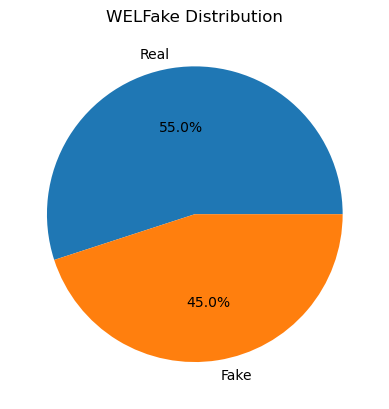

In [29]:
# ISOT
sizes = isot_df["label"].value_counts().sort_index()
plt.pie(sizes, labels=["Real","Fake"], autopct='%1.1f%%')
plt.title("ISOT Distribution")
plt.show()

# WELFake
sizes = welfake_df["label"].value_counts().sort_index()
plt.pie(sizes, labels=["Real","Fake"], autopct='%1.1f%%')
plt.title("WELFake Distribution")
plt.show()

In [32]:
tfidf_scores = []

for name, model in models.items():
    model.fit(X_train_isot_tfidf, y_train_isot)
    acc = model.score(X_test_isot_tfidf, y_test_isot)
    
    tfidf_scores.append(acc)

[LightGBM] [Info] Number of positive: 14327, number of negative: 16734
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.759641 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1194947
[LightGBM] [Info] Number of data points in the train set: 31061, number of used features: 14962
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.461254 -> initscore=-0.155297
[LightGBM] [Info] Start training from score -0.155297


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [39]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=10000)

X_train_isot_bow = bow.fit_transform(X_train_isot)
X_test_isot_bow = bow.transform(X_test_isot)
# Convert BoW to float
X_train_isot_bow = X_train_isot_bow.astype("float32")
X_test_isot_bow = X_test_isot_bow.astype("float32")

In [40]:
bow_scores = []

for name, model in models.items():
    model.fit(X_train_isot_bow, y_train_isot)
    acc = model.score(X_test_isot_bow, y_test_isot)
    
    bow_scores.append(acc)

[LightGBM] [Info] Number of positive: 14327, number of negative: 16734
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.172426 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 57979
[LightGBM] [Info] Number of data points in the train set: 31061, number of used features: 9956
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.461254 -> initscore=-0.155297
[LightGBM] [Info] Start training from score -0.155297


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


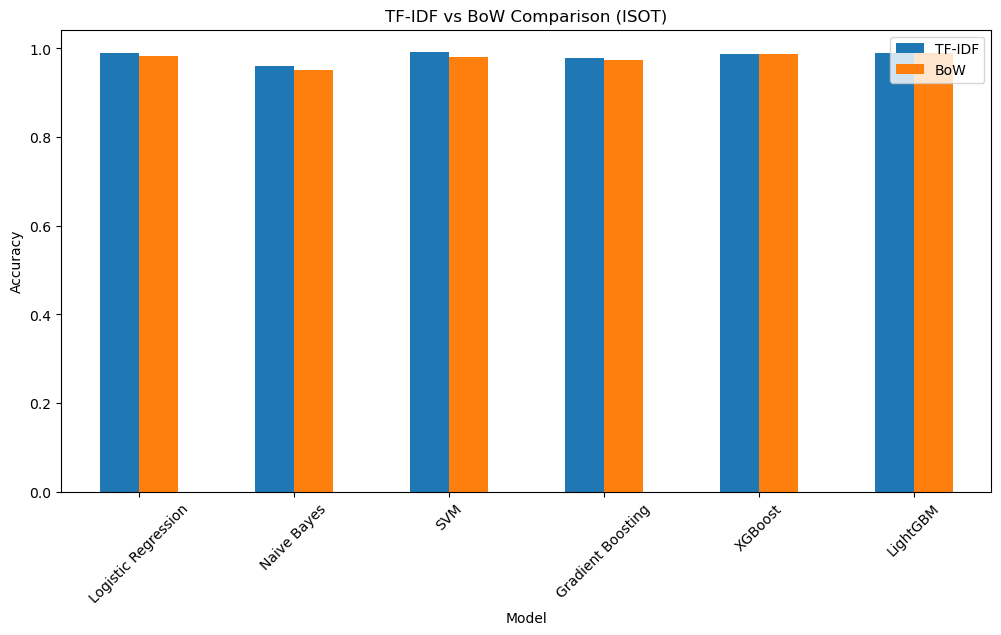

In [41]:
comparison_df = pd.DataFrame({
    "Model": list(models.keys()),
    "TF-IDF": tfidf_scores,
    "BoW": bow_scores
})

comparison_df.set_index("Model").plot(kind="bar", figsize=(12,6))

plt.title("TF-IDF vs BoW Comparison (ISOT)")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)

plt.show()

<Axes: xlabel='Dataset', ylabel='Model'>

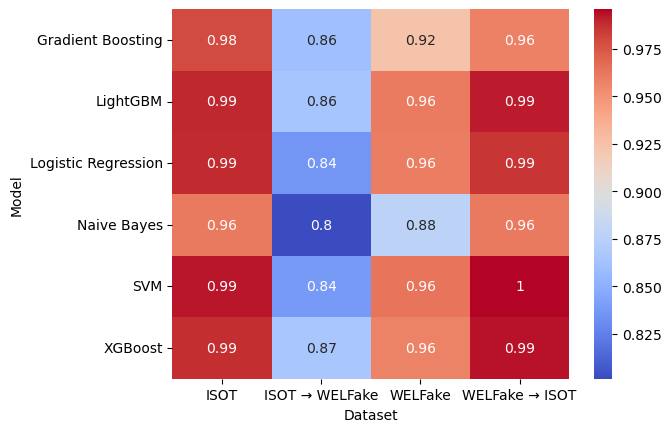

In [42]:
pivot = final_results.pivot_table(index="Model", columns="Dataset", values="Accuracy")
sns.heatmap(pivot, annot=True, cmap="coolwarm")

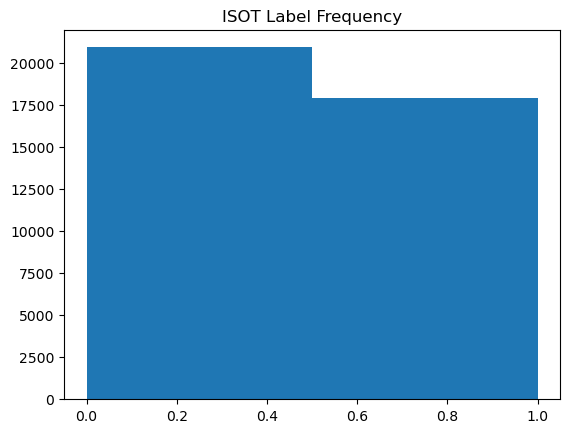

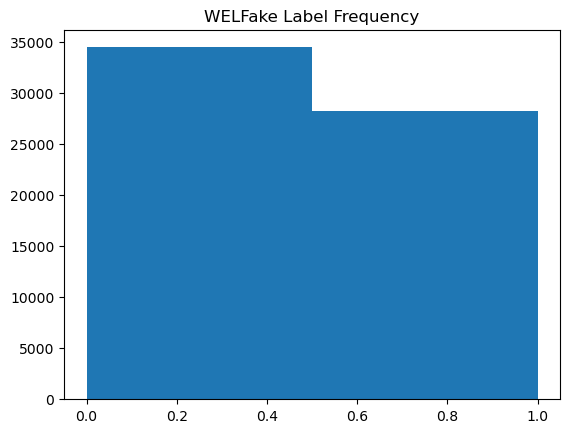

In [43]:
plt.hist(isot_df["label"], bins=2)
plt.title("ISOT Label Frequency")
plt.show()

plt.hist(welfake_df["label"], bins=2)
plt.title("WELFake Label Frequency")
plt.show()

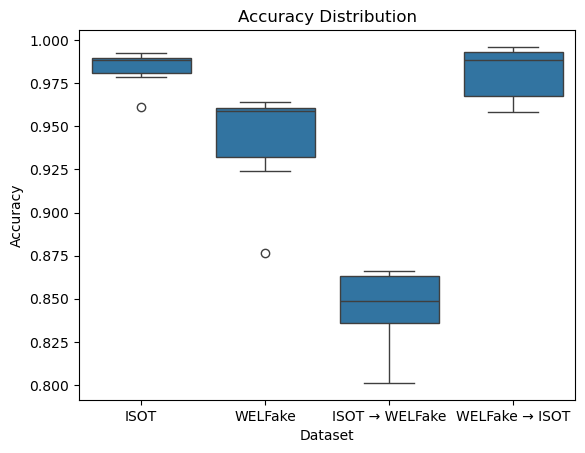

In [44]:
sns.boxplot(data=final_results, x="Dataset", y="Accuracy")
plt.title("Accuracy Distribution")
plt.show()

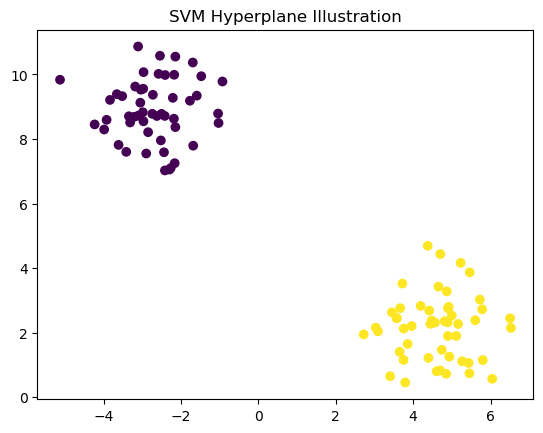

In [45]:
from sklearn import datasets
from sklearn.svm import SVC

X, y = datasets.make_blobs(n_samples=100, centers=2, random_state=42)

model = SVC(kernel='linear')
model.fit(X, y)

plt.scatter(X[:,0], X[:,1], c=y)
plt.title("SVM Hyperplane Illustration")
plt.show()

In [46]:
final_results.sort_values(by="Accuracy", ascending=False)

,Accuracy,Precision,Recall,F1 Score,Model,Dataset
20,0.996008,0.997755,0.993572,0.995659,SVM,WELFake → ISOT
22,0.993690,0.996343,0.989939,0.993131,XGBoost,WELFake → ISOT
2,0.992532,0.993827,0.989939,0.991879,SVM,ISOT
23,0.991888,0.995769,0.986585,0.991155,LightGBM,WELFake → ISOT
5,0.989827,0.992124,0.985746,0.988925,LightGBM,ISOT
0,0.988797,0.991829,0.983790,0.987793,Logistic Regression,ISOT
4,0.987767,0.989323,0.984069,0.986689,XGBoost,ISOT
18,0.985449,0.995708,0.972610,0.984024,Logistic Regression,WELFake → ISOT
3,0.978625,0.985487,0.967859,0.976593,Gradient Boosting,ISOT
8,0.963904,0.959443,0.961619,0.960530,SVM,WELFake


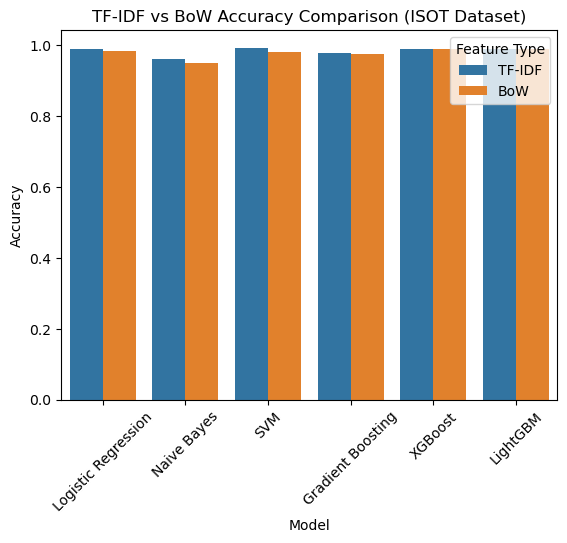

In [51]:
dataset_name = "ISOT"   # change to "WELFake" when needed

sns.barplot(
    data=comparison_df.melt(id_vars="Model"),
    x="Model",
    y="value",
    hue="variable"
)

plt.title(f"TF-IDF vs BoW Accuracy Comparison ({dataset_name} Dataset)")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=45)
plt.legend(title="Feature Type")

plt.show()

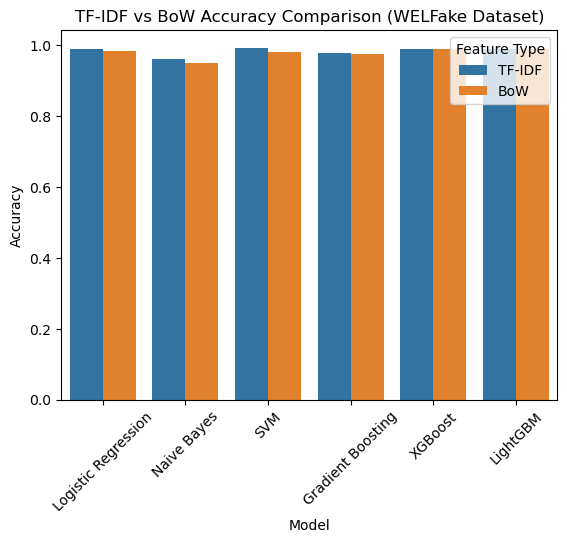

In [59]:
dataset_name = "WELFake"

sns.barplot(
    data=comparison_df.melt(id_vars="Model"),
    x="Model",
    y="value",
    hue="variable"
)

plt.title(f"TF-IDF vs BoW Accuracy Comparison ({dataset_name} Dataset)")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=45)
plt.legend(title="Feature Type")

plt.show()

In [48]:
cost_df = pd.DataFrame({
    "Method": ["TF-IDF + ML", "BoW + ML"],
    "Training Time": ["High", "Medium"],
    "Memory Usage": ["High", "Medium"],
    "Accuracy": ["Higher", "Lower"]
})

print(cost_df)

        Method Training Time Memory Usage Accuracy
0  TF-IDF + ML          High         High   Higher
1     BoW + ML        Medium       Medium    Lower


In [50]:
final_results.sort_values(by="Accuracy", ascending=False)

,Accuracy,Precision,Recall,F1 Score,Model,Dataset
20,0.996008,0.997755,0.993572,0.995659,SVM,WELFake → ISOT
22,0.993690,0.996343,0.989939,0.993131,XGBoost,WELFake → ISOT
2,0.992532,0.993827,0.989939,0.991879,SVM,ISOT
23,0.991888,0.995769,0.986585,0.991155,LightGBM,WELFake → ISOT
5,0.989827,0.992124,0.985746,0.988925,LightGBM,ISOT
0,0.988797,0.991829,0.983790,0.987793,Logistic Regression,ISOT
4,0.987767,0.989323,0.984069,0.986689,XGBoost,ISOT
18,0.985449,0.995708,0.972610,0.984024,Logistic Regression,WELFake → ISOT
3,0.978625,0.985487,0.967859,0.976593,Gradient Boosting,ISOT
8,0.963904,0.959443,0.961619,0.960530,SVM,WELFake


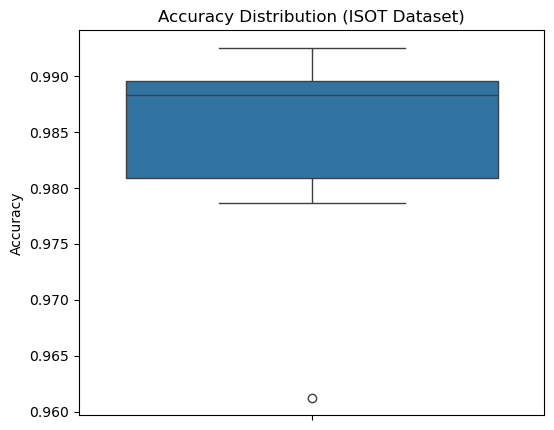

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter ISOT data
df_isot = final_results[final_results["Dataset"] == "ISOT"]

plt.figure(figsize=(6,5))

sns.boxplot(
    data=df_isot,
    y="Accuracy"
)

plt.title("Accuracy Distribution (ISOT Dataset)")
plt.ylabel("Accuracy")

plt.show()

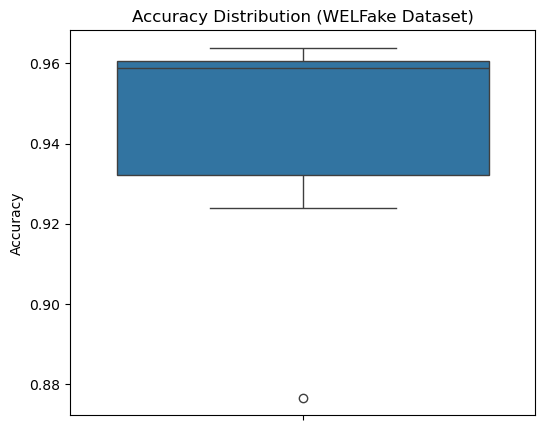

In [58]:
# Filter WELFake data
df_wel = final_results[final_results["Dataset"] == "WELFake"]

plt.figure(figsize=(6,5))

sns.boxplot(
    data=df_wel,
    y="Accuracy"
)

plt.title("Accuracy Distribution (WELFake Dataset)")
plt.ylabel("Accuracy")

plt.show()

In [62]:
import pandas as pd

# Filter only main datasets
df_main = final_results[
    final_results["Dataset"].isin(["ISOT", "WELFake"])
]

# Get top model for each dataset
top_isot = df_main[df_main["Dataset"] == "ISOT"].sort_values(by="Accuracy", ascending=False).head(1)
top_wel = df_main[df_main["Dataset"] == "WELFake"].sort_values(by="Accuracy", ascending=False).head(1)

# Combine
top_table = pd.concat([top_isot, top_wel])

# Select required columns
top_table = top_table[["Dataset", "Model", "Accuracy"]]

print(top_table)

   Dataset Model  Accuracy
2     ISOT   SVM  0.992532
8  WELFake   SVM  0.963904
